In [9]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [10]:
df = pd.read_csv("hotel_reviews_dataset.csv")  
df.head()


,Hotel,ReviewerName,Nationality,ReviewDate,OverallRating,ReviewText,Cleanliness,Location,Comfort,Facilities,Staff,Value for Money,Free WiFi
0,Urban Comfort,Brian Garcia,Mozambique,2024-08-13,5.7,Watch red lot water lot window staff anything ...,5.0,8.6,7.1,5.3,7.4,6.1,8.4
1,Hotel Elegance,Cassandra Wade,Northern Mariana Islands,2024-05-03,8.9,Class nation spring inside per walk table film...,9.9,9.8,6.6,7.4,7.0,6.9,6.9
2,Sunset Retreat,John Williams,Guinea-Bissau,2024-04-02,7.5,Class hot everyone city economy network eight ...,9.9,9.2,8.9,7.2,7.5,5.4,6.6
3,Urban Comfort,Taylor French,Tanzania,2025-01-25,6.9,Whatever thank effect development security bre...,7.4,8.5,8.9,5.6,5.2,7.1,7.1
4,Urban Comfort,Michael Soto,Chad,2023-08-11,6.8,Leg administration career wish responsibility ...,5.2,9.4,8.4,6.0,9.3,7.0,8.3


In [11]:
# Simulate sentiment from ratings
def label_sentiment(rating):
    if rating >= 8.0:
        return "Positive"
    elif rating >= 6.0:
        return "Neutral"
    else:
        return "Negative"

df['Sentiment'] = df['OverallRating'].apply(label_sentiment)
df[['ReviewText', 'OverallRating', 'Sentiment']].head()


,ReviewText,OverallRating,Sentiment
0,Watch red lot water lot window staff anything ...,5.7,Negative
1,Class nation spring inside per walk table film...,8.9,Positive
2,Class hot everyone city economy network eight ...,7.5,Neutral
3,Whatever thank effect development security bre...,6.9,Neutral
4,Leg administration career wish responsibility ...,6.8,Neutral


In [12]:
X = df['ReviewText']
y = df['Sentiment']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [13]:
# Vectorize text using TF-IDF
tfidf = TfidfVectorizer(max_features=1000, stop_words='english')
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

In [14]:
# Train a Logistic Regression model
model = LogisticRegression(max_iter=200)
model.fit(X_train_tfidf, y_train)

LogisticRegression(max_iter=200)

In [15]:
# Predict on test data
y_pred = model.predict(X_test_tfidf)

# Classification report
report = classification_report(y_test, y_pred)
print(report)


              precision    recall  f1-score   support

    Negative       0.16      0.04      0.06       180
     Neutral       0.45      0.47      0.46       412
    Positive       0.43      0.56      0.49       408

    accuracy                           0.43      1000
   macro avg       0.35      0.36      0.34      1000
weighted avg       0.39      0.43      0.40      1000



In [16]:
# Add predictions to test data
df_test = X_test.reset_index(drop=True).to_frame()
df_test['Actual'] = y_test.reset_index(drop=True)
df_test['Predicted'] = y_pred

# Save to file
df_test.to_csv("review_sentiment_predictions.csv", index=False)

# EDA 


In [17]:
df.describe(include='all')

,Hotel,ReviewerName,Nationality,ReviewDate,OverallRating,ReviewText,Cleanliness,Location,Comfort,Facilities,Staff,Value for Money,Free WiFi,Sentiment
count,5000,5000,5000,5000,5000.000000,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000
unique,3,4821,243,730,NaN,5000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3
top,Sunset Retreat,David Smith,Congo,2023-05-16,NaN,Should research rich over family difference ne...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Positive
freq,1713,4,39,17,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2069
mean,NaN,NaN,NaN,NaN,7.527260,NaN,7.482840,7.491460,7.492980,7.496280,7.501680,7.514340,7.511880,NaN
std,NaN,NaN,NaN,NaN,1.448189,NaN,1.437578,1.422228,1.440612,1.453812,1.435502,1.450941,1.433399,NaN
min,NaN,NaN,NaN,NaN,5.000000,NaN,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,NaN
25%,NaN,NaN,NaN,NaN,6.300000,NaN,6.300000,6.300000,6.300000,6.200000,6.300000,6.275000,6.300000,NaN
50%,NaN,NaN,NaN,NaN,7.500000,NaN,7.500000,7.500000,7.500000,7.500000,7.500000,7.500000,7.500000,NaN
75%,NaN,NaN,NaN,NaN,8.800000,NaN,8.700000,8.700000,8.700000,8.800000,8.700000,8.800000,8.700000,NaN


<Axes: title={'center': 'Number of Reviews per Hotel'}, ylabel='count'>

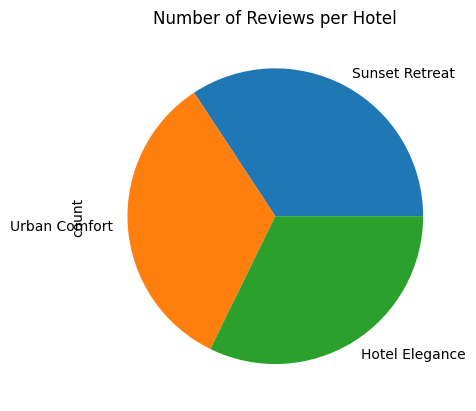

In [22]:
df['Hotel'].value_counts().plot(kind='pie', title='Number of Reviews per Hotel')

<Axes: title={'center': 'Average Rating per Hotel'}, xlabel='Hotel'>

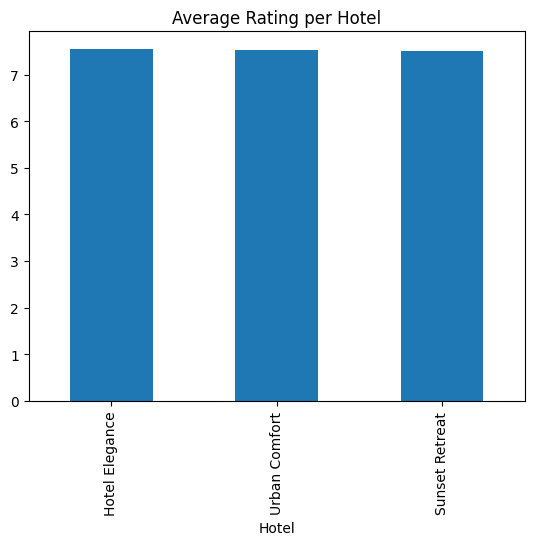

In [23]:
df.groupby('Hotel')['OverallRating'].mean().sort_values(ascending=False).plot(kind='bar', title='Average Rating per Hotel')

<Axes: title={'center': 'Sentiment Distribution'}, ylabel='count'>

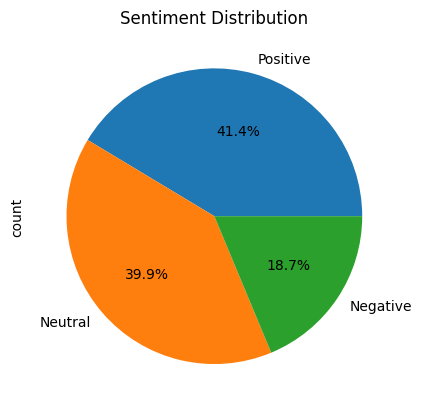

In [26]:
df['Sentiment'].value_counts().plot(kind='pie', autopct='%1.1f%%', title='Sentiment Distribution')

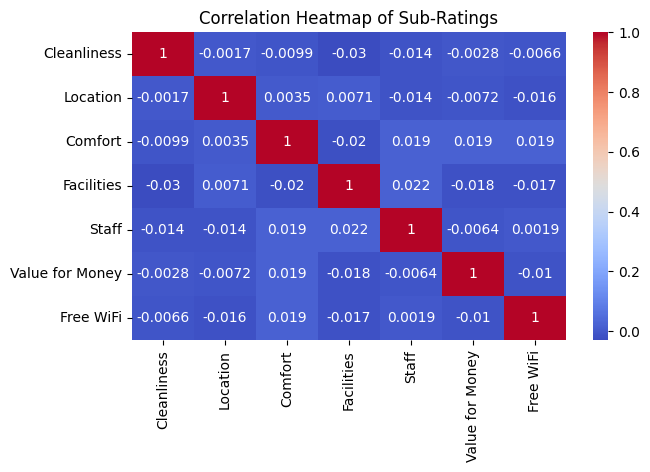

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sub_rating_cols = ['Cleanliness', 'Location', 'Comfort', 'Facilities', 'Staff', 'Value for Money', 'Free WiFi']
plt.figure(figsize=(7, 4))
sns.heatmap(df[sub_rating_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Sub-Ratings')
plt.show()